Sube el archivo CSV cuando aparezca el botón...


Saving consumo_hogar.csv to consumo_hogar (3).csv


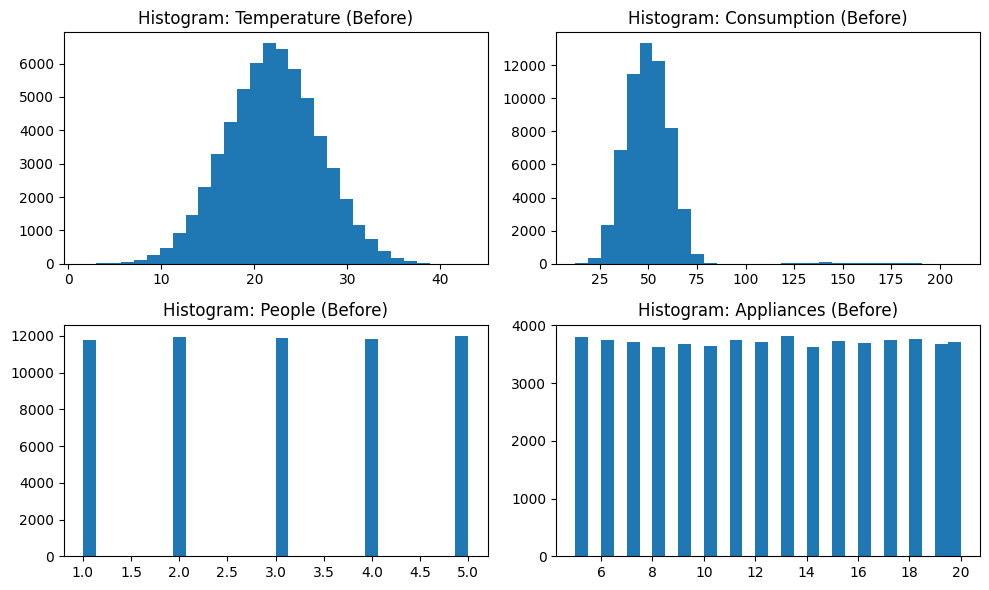

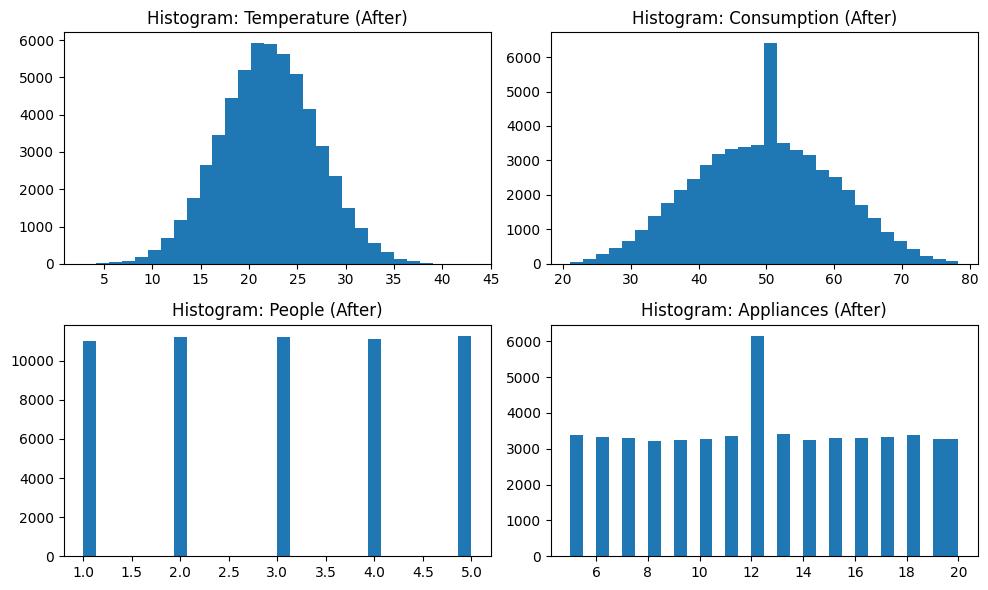

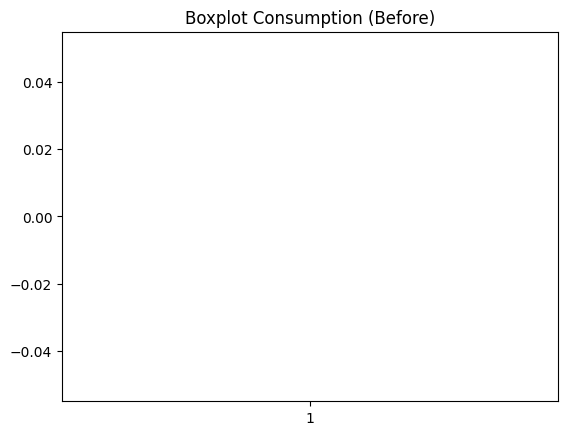

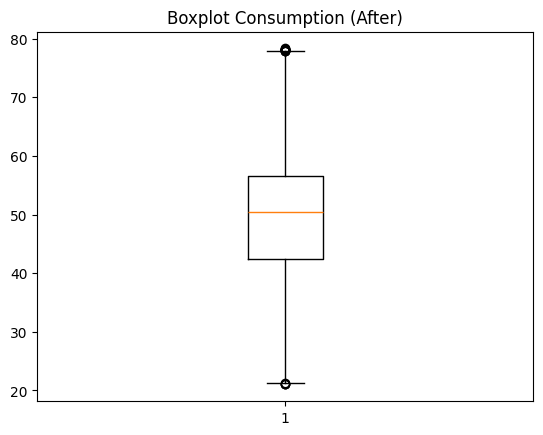

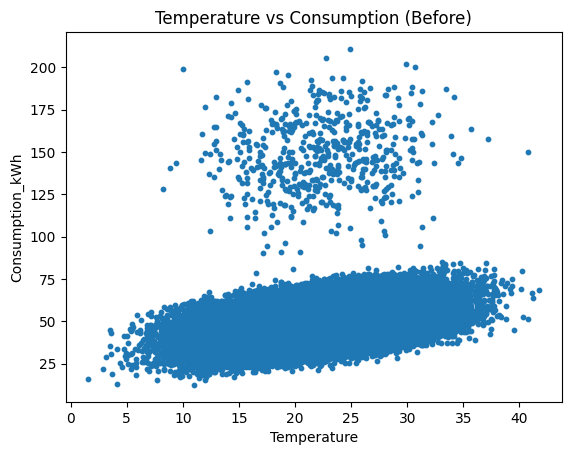

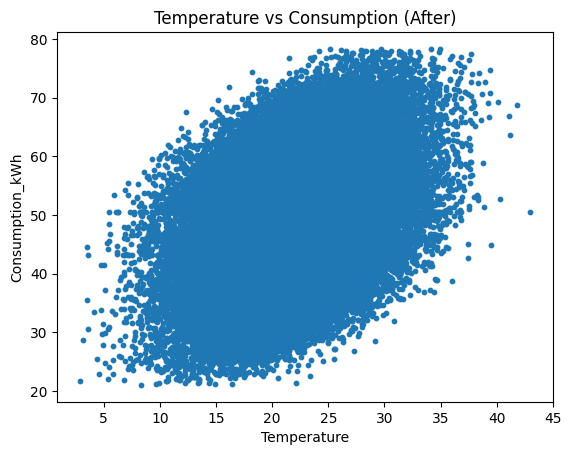

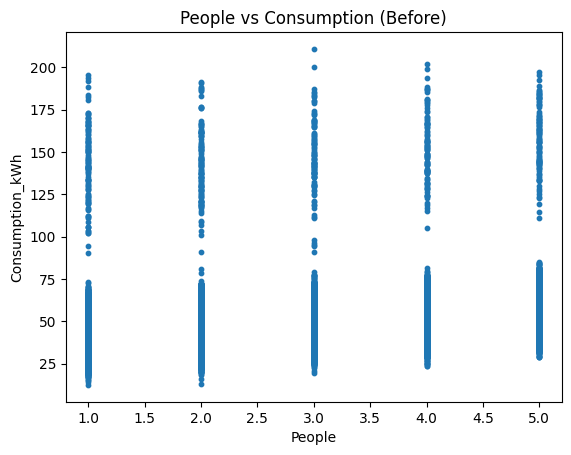

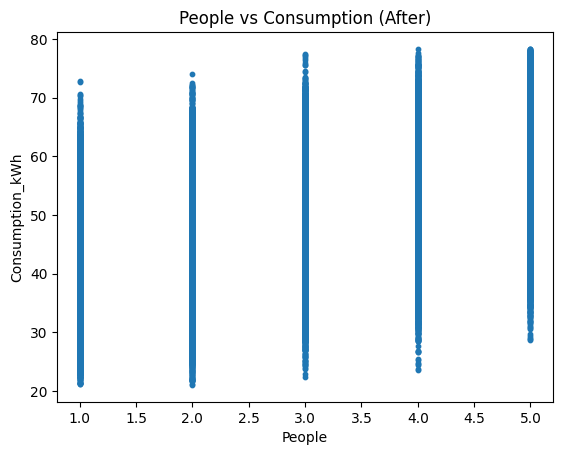

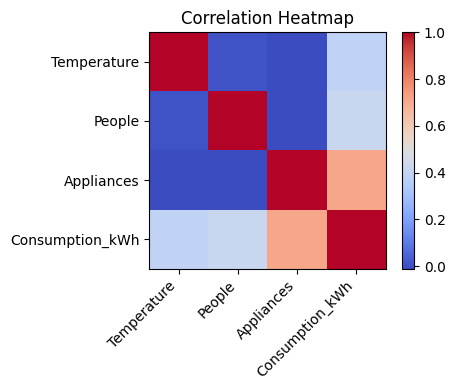


=== MODEL METRICS ===
Linear Regression     -> MSE: 16.0003 | R2: 0.8452
Polynomial Degree 2   -> MSE: 16.0049 | R2: 0.8451
Polynomial Degree 3   -> MSE: 15.9998 | R2: 0.8452


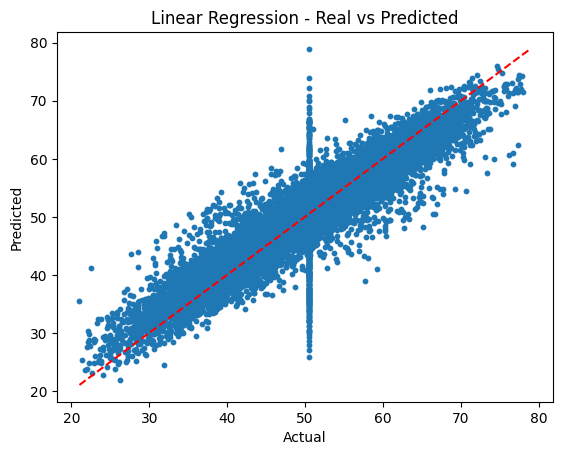

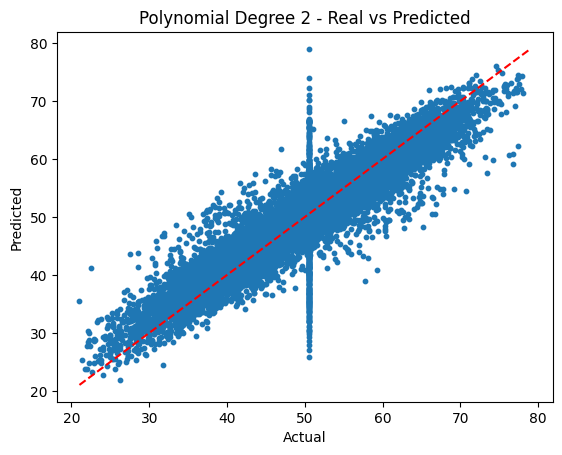

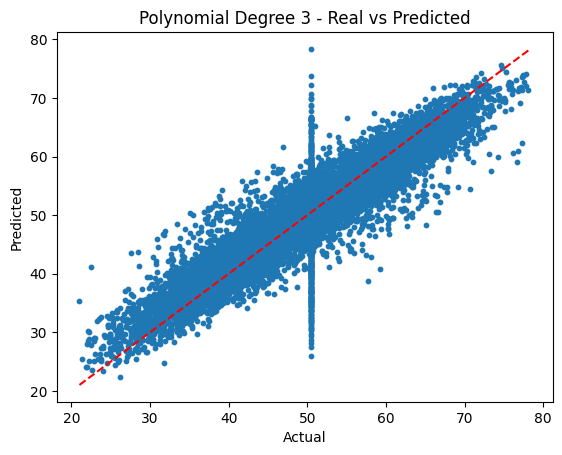

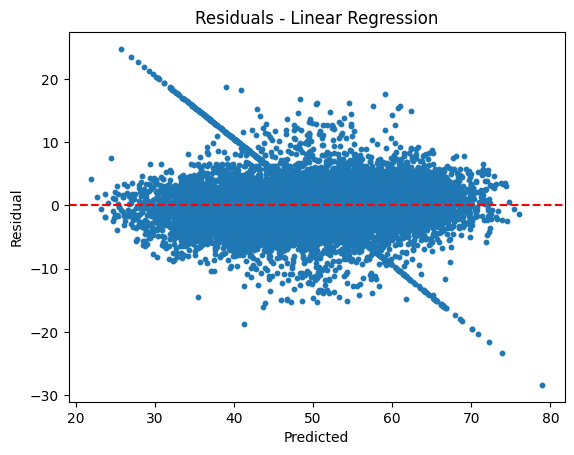

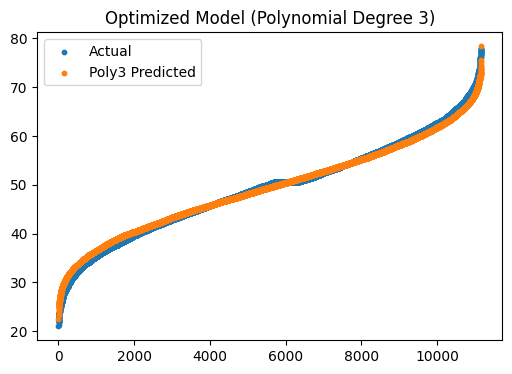

In [4]:
# ============================================
# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files

# ============================================
# 2. LOAD CSV
# ============================================
print("Sube el archivo CSV cuando aparezca el botón...")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

# ============================================
# 3. RENAME COLUMNS
# ============================================
df = df.rename(columns={
    'Temperatura': 'Temperature',
    'Personas': 'People',
    'Electrodomesticos': 'Appliances',
    'Consumo_kWh': 'Consumption_kWh'
})

# Reservamos BEFORE
df_before = df[['Temperature','People','Appliances','Consumption_kWh']].copy()

# ============================================
# 4. MISSING VALUES RULE (<= 5% drop, otherwise mean)
# ============================================
n_total = len(df)
for col in df.columns:
    miss_pct = df[col].isna().mean()
    if miss_pct <= 0.05:
        df = df.dropna(subset=[col])
    else:
        if df[col].dtype != 'O':
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])

# ============================================
# 5. OUTLIERS WITH IQR (target only)
# ============================================
Q1 = df['Consumption_kWh'].quantile(0.25)
Q3 = df['Consumption_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[df['Consumption_kWh'].between(lower, upper)]

# ============================================
# 6. HISTOGRAMS BEFORE
# ============================================
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
cols = ['Temperature','Consumption_kWh','People','Appliances']
titles = ['Histogram: Temperature (Before)', 'Histogram: Consumption (Before)',
          'Histogram: People (Before)', 'Histogram: Appliances (Before)']

for ax, col, title in zip(axes, cols, titles):
    ax.hist(df_before[col], bins=30)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# ============================================
# 7. HISTOGRAMS AFTER
# ============================================
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
titles = ['Histogram: Temperature (After)', 'Histogram: Consumption (After)',
          'Histogram: People (After)', 'Histogram: Appliances (After)']

for ax, col, title in zip(axes, cols, titles):
    ax.hist(df[col], bins=30)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# ============================================
# 8. BOXPLOT BEFORE
# ============================================
plt.boxplot(df_before['Consumption_kWh'])
plt.title("Boxplot Consumption (Before)")
plt.show()

# ============================================
# 9. BOXPLOT AFTER
# ============================================
plt.boxplot(df['Consumption_kWh'])
plt.title("Boxplot Consumption (After)")
plt.show()

# ============================================
# 10. SCATTER BEFORE (Temperature-Consumption)
# ============================================
plt.scatter(df_before['Temperature'], df_before['Consumption_kWh'], s=10)
plt.title("Temperature vs Consumption (Before)")
plt.xlabel("Temperature")
plt.ylabel("Consumption_kWh")
plt.show()

# ============================================
# 11. SCATTER AFTER (Temperature-Consumption)
# ============================================
plt.scatter(df['Temperature'], df['Consumption_kWh'], s=10)
plt.title("Temperature vs Consumption (After)")
plt.xlabel("Temperature")
plt.ylabel("Consumption_kWh")
plt.show()

# ============================================
# 12. SCATTER BEFORE (People-Consumption)
# ============================================
plt.scatter(df_before['People'], df_before['Consumption_kWh'], s=10)
plt.title("People vs Consumption (Before)")
plt.xlabel("People")
plt.ylabel("Consumption_kWh")
plt.show()

# ============================================
# 13. SCATTER AFTER (People-Consumption)
# ============================================
plt.scatter(df['People'], df['Consumption_kWh'], s=10)
plt.title("People vs Consumption (After)")
plt.xlabel("People")
plt.ylabel("Consumption_kWh")
plt.show()

# ============================================
# 14. HEATMAP WITH MATPLOTLIB
# ============================================
corr = df[['Temperature','People','Appliances','Consumption_kWh']].corr()
fig, ax = plt.subplots(figsize=(5,4))
cax = ax.imshow(corr, cmap='coolwarm')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
fig.colorbar(cax)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================
# 15. TRAIN-TEST SPLIT
# ============================================
X = df[['Temperature','People','Appliances']].values
y = df['Consumption_kWh'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================================
# 16. MODELS: LINEAR, POLY2, POLY3
# ============================================
# Linear
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Poly2
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2.fit(X_train, y_train)
y_pred_p2 = poly2.predict(X_test)

# Poly3
poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly3.fit(X_train, y_train)
y_pred_p3 = poly3.predict(X_test)

# ============================================
# 17. PRINT METRICS
# ============================================
print("\n=== MODEL METRICS ===")
print(f"Linear Regression     -> MSE: {mean_squared_error(y_test,y_pred_lr):.4f} | R2: {r2_score(y_test,y_pred_lr):.4f}")
print(f"Polynomial Degree 2   -> MSE: {mean_squared_error(y_test,y_pred_p2):.4f} | R2: {r2_score(y_test,y_pred_p2):.4f}")
print(f"Polynomial Degree 3   -> MSE: {mean_squared_error(y_test,y_pred_p3):.4f} | R2: {r2_score(y_test,y_pred_p3):.4f}")

# ============================================
# 18. PRED VS ACTUAL (3 FIGURES)
# ============================================
models = [("Linear Regression", y_pred_lr),
          ("Polynomial Degree 2", y_pred_p2),
          ("Polynomial Degree 3", y_pred_p3)]

for name, pred in models:
    plt.scatter(y_test, pred, s=10)
    plt.title(f"{name} - Real vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.show()

# ============================================
# 19. RESIDUALS (LINEAR)
# ============================================
residuals = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals - Linear Regression")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

# ============================================
# 20. OPTIMIZED MODEL (POLY3 VISUAL)
# ============================================
plt.figure(figsize=(6,4))
plt.scatter(range(len(y_test)), sorted(y_test), label="Actual", s=10)
plt.scatter(range(len(y_pred_p3)), sorted(y_pred_p3), label="Poly3 Predicted", s=10)
plt.legend()
plt.title("Optimized Model (Polynomial Degree 3)")
plt.show()
# FIGURE 19 - Residuals of Linear Regression
y_pred_lr = lr.predict(X_test)
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Consumption (Linear Model)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals of the Linear Model (Figure 19)")
plt.grid(True)
plt.show()
# FIGURE 20 - Optimized Model (Polynomial Degree 2) - Actual vs Predicted
y_pred_poly2 = poly2_model.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_poly2, alpha=0.7)
plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption")
plt.title("Optimized Model (Polynomial Degree 2) - Actual vs Predicted (Figure 20)")
plt.grid(True)
plt.show()


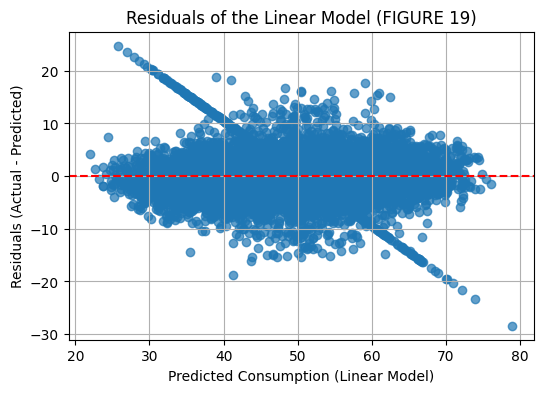

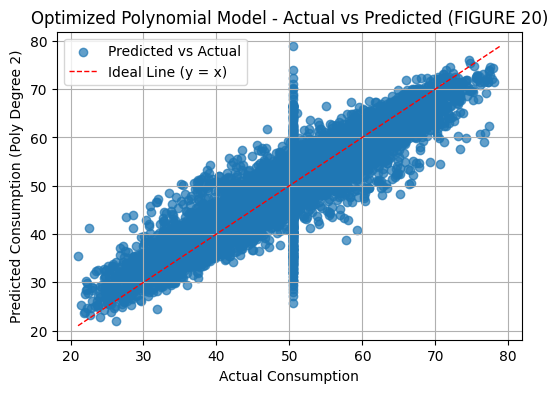

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# FIGURA 19 - RESIDUALES (LINEAR REGRESSION)
# =========================
y_pred_lr = lr.predict(X_test)
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Consumption (Linear Model)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals of the Linear Model (FIGURE 19)")
plt.grid(True)
plt.show()


# =========================
# FIGURA 20 - OPTIMIZED MODEL (POLYNOMIAL DEGREE 2)
# =========================
y_pred_poly2 = poly2.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_poly2, alpha=0.7, label='Predicted vs Actual')
mn = float(min(y_test.min(), y_pred_poly2.min()))
mx = float(max(y_test.max(), y_pred_poly2.max()))
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='Ideal Line (y = x)')
plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption (Poly Degree 2)")
plt.title("Optimized Polynomial Model - Actual vs Predicted (FIGURE 20)")
plt.legend()
plt.grid(True)
plt.show()
